# 실습 6-2 : STUCCO (대조집합 학습)

#### **<실습 내용>**

1. 대조집합 학습 개요
- STUCCO 알고리즘 원리

2. STUCCO 기본 예제 (Process_Data)
- 데이터 전처리 (연속형 변수 범주화)
- 대조집합(cset) 도출 및 해석

3. Vibe Coding 실습 (통신사 고객 이탈 데이터)

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

import logging
from stucco import ContrastSetLearner  # 대조집합 학습(Contrast Set Learning)을 수행하는 STUCCO 알고리즘 구현체

logging.getLogger().setLevel(logging.WARNING)  # stucco.py의 상세 진행 로그 숨기기


def setup_korean_font():
    """matplotlib/seaborn 한글 폰트 적용. sns.set_theme() 호출 후 재호출 필요."""
    korean_fonts = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"]
    available = {f.name for f in fm.fontManager.ttflist}
    for font in korean_fonts:
        if font in available:
            plt.rcParams["font.family"] = font
            break
    plt.rcParams["axes.unicode_minus"] = False


sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
setup_korean_font()

---

## 1) 데이터 불러오기

In [2]:
data = pd.read_csv("dataset/day6-2_data.csv")
print("데이터 크기:", data.shape)
data.head()

데이터 크기: (596, 12)


,Prod_ID,M1,M2,P1,P2,P3,C1,C2,P4,P5,P6,Y
0,1001001,15,E,A,B,D,110.192,27.049,A,A,B,0
1,1001002,20,E,A,B,D,109.940,27.215,A,A,A,0
2,1001003,15,U,A,B,B,110.214,27.444,B,B,B,4
3,1001004,25,K,B,B,C,107.260,27.300,A,A,C,0
4,1001005,20,E,A,A,D,105.026,28.283,B,B,A,0


In [3]:
# 불량 기준 설정: 제품 1개당 불량 개수(Y)가 3개 이상이면 Fault, 아니면 Pass로 그룹 라벨 생성
data["Fail"] = ["Fault" if i >= 3 else "Pass" for i in data["Y"]]
data

,Prod_ID,M1,M2,P1,P2,P3,C1,C2,P4,P5,P6,Y,Fail
0,1001001,15,E,A,B,D,110.192,27.049,A,A,B,0,Pass
1,1001002,20,E,A,B,D,109.940,27.215,A,A,A,0,Pass
2,1001003,15,U,A,B,B,110.214,27.444,B,B,B,4,Fault
3,1001004,25,K,B,B,C,107.260,27.300,A,A,C,0,Pass
4,1001005,20,E,A,A,D,105.026,28.283,B,B,A,0,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,1001592,15,E,A,C,D,115.153,31.652,A,A,C,0,Pass
592,1001593,15,E,A,B,D,114.593,33.890,A,A,B,0,Pass
593,1001594,20,U,A,A,B,105.724,33.251,B,B,A,0,Pass
594,1001595,25,E,A,A,A,109.783,32.054,A,A,D,0,Pass


In [4]:
print("클래스 분포:")
print(data["Fail"].value_counts())

클래스 분포:
Fail
Pass     471
Fault    125
Name: count, dtype: int64


**활용할 반도체 공정 데이터 소개 (6-1과 동일)**

| 변수 | 설명 |
|---|---|
| Prod_ID | 제품 고유 ID |
| M1 | 공정 설비 온도 설정값 (15/20/25/30) |
| M2 | 사용 설비 ID (E, U, K) |
| P1 ~ P6 | 제품 설계/공정 옵션 (범주형 파라미터) |
| C1, C2 | 공정 중 측정된 연속형 값 |
| Y | 제품 1개당 발생한 불량 개수 |
| Fail | Y >= 3이면 Fault, 아니면 Pass로 정의한 라벨 |

## 2) 전처리하기

> STUCCO는 입력변수로 **범주형 변수만** 허용하므로 연속형 변수(C1, C2)는 구간화하여 범주형 변수 처럼 나타내야함

In [5]:
# 1. M1
# 숫자(15/20/25/30)로 저장되어 있음
# 그러나 실제로는 '온도 설정값'을 의미하는 범주이므로 범주형으로 변환
data["M1"] = data["M1"].astype("object")

# 2. 연속형 변수 C1, C2
# qcut: 데이터 개수가 균등하도록 4구간으로 분할
data["C1_cut"] = pd.qcut(data["C1"], 4)
# cut: 의미 있는 경계값 기준으로 직접 3구간 지정
data["C2_cut"] = pd.cut(data["C2"], bins=[18, 28, 32, 39], labels=["Low", "Normal", "High"]) 

### 2-1) STUCCO 실행

1. 비교할 그룹 설정
2. Contrast Set 후보 규칙 생성
3. 유의미한 규칙 추출

In [6]:
# STUCCO에 불필요한 변수 제거
# (ID, 이미 구간화한 원본 연속형 변수, 라벨 만드는 데 쓴 Y)
contra_data = data.drop(["Prod_ID", "C1", "C2", "Y"], axis=1)
contra_data

,M1,M2,P1,P2,P3,P4,P5,P6,Fail,C1_cut,C2_cut
0,15,E,A,B,D,A,A,B,Pass,"(109.191, 112.225]",Low
1,20,E,A,B,D,A,A,A,Pass,"(109.191, 112.225]",Low
2,15,U,A,B,B,B,B,B,Fault,"(109.191, 112.225]",Low
3,25,K,B,B,C,A,A,C,Pass,"(106.365, 109.191]",Low
4,20,E,A,A,D,B,B,A,Pass,"(102.158, 106.365]",Normal
...,...,...,...,...,...,...,...,...,...,...,...
591,15,E,A,C,D,A,A,C,Pass,"(112.225, 123.34]",Normal
592,15,E,A,B,D,A,A,B,Pass,"(112.225, 123.34]",High
593,20,U,A,A,B,B,B,A,Pass,"(102.158, 106.365]",High
594,25,E,A,A,A,A,A,D,Pass,"(109.191, 112.225]",High


> 1. 비교할 그룹 설정 (ContrastSetLearner())

In [7]:
# ContrastSetLearner(DataFrame, group_feature)

# "Fail" 컬럼의 그룹을 기준으로 Contrast Set 탐색
# Contrast Set: 그룹 간 차이를 가장 잘 설명하는 규칙

learner = ContrastSetLearner(contra_data, group_feature="Fail")
learner

> 2. Contrast Set 후보 규칙 생성 (learn())

In [8]:
# learner.learn():
# 그룹 간 차이를 설명할 수 있는 규칙 후보(조건 조합)를 생성
# 각 규칙의 그룹별 등장 빈도를 계산

# max_length: 규칙을 구성하는 최대 조건 수
# n_matrices: 규칙이 각 그룹에서 몇 번 나타났는지 등의 빈도 정보를 저장

n_matrices = learner.learn(max_length=3)
n_matrices

4217

> 3. 유의미한 규칙 추출 (score())

In [9]:
# learner.score():
# learn( )에서 생성한 빈도 정보를 활용해 규칙별 Support, Confidence, Lift를 계산

# Support: 규칙의 출현 비율
# Confidence: 규칙이 나타났을 때 해당 그룹일 확률
# Lift: 특정 그룹과의 연관성 정도

# lift가 2.0 이상인(특정 그룹과의 연관성 정도) 규칙만 채택
contrast_rules = learner.score(min_lift=2.0)
contrast_rules

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fail=>Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fail=>Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fail=>Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fail=>Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fail=>Fault,2.300000
5,"(P1=>A, P6=>D, C1_cut=>(106.365, 109.191])",Fail=>Fault,2.258065
9,"(M2=>K, P1=>A, P2=>B)",Fail=>Fault,2.250000
10,"(P1=>A, P5=>B, C1_cut=>(112.225, 123.34])",Fail=>Fault,2.222222
8,"(P1=>A, P3=>D, P6=>D)",Fail=>Fault,2.181818
16,"(M1=>25, M2=>K, P1=>A)",Fail=>Fault,2.181818


In [10]:
# group 컬럼 값이 "Fail=>Fault", "Fail=>Pass" 형태로 저장되어 있음
# 보기 쉽게 "Fault", "Pass"만 남도록 문자열 변경
contrast_rules["group"] = contrast_rules["group"].str.replace("Fail=>", "")

# learn() 단계에서 생성된 전체 조건 조합(규칙 후보) 수 출력
print("생성된 조건 조합 수:", n_matrices)

# score() 단계의 기준을 통과하여 최종 선택된 Contrast Set 규칙 수 출력
print("도출된 규칙 수:", contrast_rules.shape[0])

생성된 조건 조합 수: 4217
도출된 규칙 수: 17


### 2-2) 결과 해석

In [11]:
# 도출된 규칙 확인
# 실제로는 Pass 규칙도 있었는데 score 기준에 따라 필터링 된 것임

contrast_rules.head()

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fault,2.300000


In [12]:
# Fault 그룹을 설명하는 규칙만 추출
fault_rules = contrast_rules.loc[contrast_rules["group"] == "Fault"]

# Lift 기준 상위 5개 규칙 확인
fault_rules.sort_values(by="lift", ascending=False).head()

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fault,2.300000


In [13]:
# Lift가 가장 높은 Contrast Set 규칙
# (P1=A) AND (P3=A) AND (C2_cut=High)를 만족하는 데이터 선택

cset_mask = (data["P1"] == "A") & (data["P3"] == "A") & (data["C2_cut"] == "High")

# 규칙을 만족하는 데이터의 불량(Fail) 분포 확인
print("cset 해당 데이터 불량 분포:")
print(data.loc[cset_mask, "Fail"].value_counts())
print()

# 규칙을 만족하지 않는 데이터의 불량(Fail) 분포 확인
print("cset 미해당 데이터 불량 분포:")
print(data.loc[~cset_mask, "Fail"].value_counts())

cset 해당 데이터 불량 분포:
Fail
Fault    12
Pass      6
Name: count, dtype: int64

cset 미해당 데이터 불량 분포:
Fail
Pass     465
Fault    113
Name: count, dtype: int64


---

## 3) Vibe Coding 실습 (통신사 고객 이탈 데이터)

STUCCO를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 직접 적용해 봅니다.

- `dataset/day6_vibecoding.csv` 파일 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

데이터 크기: (7043, 20)

Churn 분포:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


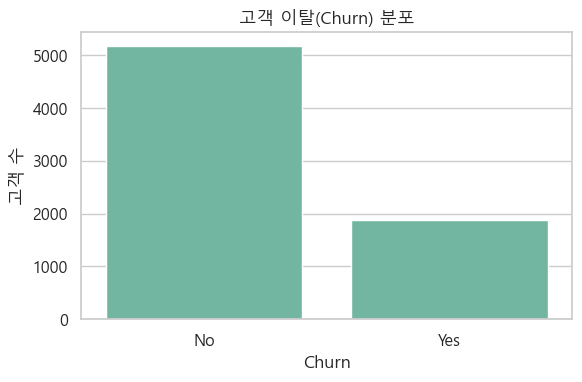

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,tenure_cut,MonthlyCharges_cut,TotalCharges_cut
0,Female,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No,"(-0.001, 9.0]","(18.249, 39.025]","(18.799, 402.225]"
1,Male,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No,"(29.0, 55.0]","(39.025, 70.3]","(1397.475, 3786.6]"
2,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes,"(-0.001, 9.0]","(39.025, 70.3]","(18.799, 402.225]"
3,Male,No,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No,"(29.0, 55.0]","(39.025, 70.3]","(1397.475, 3786.6]"
4,Female,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes,"(-0.001, 9.0]","(70.3, 89.6]","(18.799, 402.225]"


In [14]:
# 필요한 라이브러리 호출하기
from sklearn.impute import KNNImputer

# Seaborn 테마 + 한글 폰트 (set_theme 이후 폰트가 초기화될 수 있어 재적용)
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
setup_korean_font()

# 0. 데이터 불러오기
data = pd.read_csv("dataset/day6_vibecoding.csv")
print("데이터 크기:", data.shape)

# 1. 결측치 처리
for col in ["InternetService", "PaymentMethod"]:
    data[col] = data[col].fillna(data[col].mode()[0])

data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())

knn_cols = ["tenure", "MonthlyCharges"]
imputer = KNNImputer(n_neighbors=5)
data[knn_cols] = imputer.fit_transform(data[knn_cols])

# 2. STUCCO용 전처리: 연속형 변수는 qcut으로 구간화, 범주형은 그대로 유지
data["tenure_cut"] = pd.qcut(data["tenure"], 4, duplicates="drop")
data["MonthlyCharges_cut"] = pd.qcut(data["MonthlyCharges"], 4, duplicates="drop")
data["TotalCharges_cut"] = pd.qcut(data["TotalCharges"], 4, duplicates="drop")
data["SeniorCitizen"] = data["SeniorCitizen"].map({0: "No", 1: "Yes"}).astype("object")

# STUCCO 입력: 원본 연속형 컬럼 제거 후 Churn 포함
stucco_data = data.drop(columns=["tenure", "MonthlyCharges", "TotalCharges"])

print("\nChurn 분포:")
print(stucco_data["Churn"].value_counts())

# 타겟 분포 시각화
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=stucco_data, x="Churn", order=["No", "Yes"], ax=ax)
ax.set_title("고객 이탈(Churn) 분포")
ax.set_xlabel("Churn")
ax.set_ylabel("고객 수")
plt.tight_layout()
plt.show()

stucco_data.head()

**[과제]** 본 데이터셋에서의 연속형 범수인 'tenure', 'MonthlyCharges', 'TotalCharges'를 `pd.qcut` 등으로 구간화하고 `ContrastSetLearner`로 Churn(Yes/No) 그룹 간 대조집합을 도출하는 코드를 AI와 상의해서 작성하세요.

In [15]:
# [과제 1] STUCCO로 Churn(Yes/No) 그룹 간 대조집합 도출
learner = ContrastSetLearner(stucco_data, group_feature="Churn")
n_matrices = learner.learn(max_length=3)
contrast_rules = learner.score(min_lift=2.0)
contrast_rules["group"] = contrast_rules["group"].str.replace("Churn=>", "")

print("생성된 조건 조합 수:", n_matrices)
print("도출된 규칙 수:", contrast_rules.shape[0])
contrast_rules.head(10)

생성된 조건 조합 수: 20223
도출된 규칙 수: 326


,rule,group,lift
257,"(InternetService=>Fiber optic, PaymentMethod=>...",Yes,4.626094
142,"(StreamingMovies=>Yes, Contract=>Month-to-mont...",Yes,4.591801
295,"(MultipleLines=>Yes, InternetService=>Fiber op...",Yes,4.556219
122,"(StreamingTV=>Yes, Contract=>Month-to-month, t...",Yes,4.485980
258,"(InternetService=>Fiber optic, MonthlyCharges_...",Yes,4.431675
309,"(SeniorCitizen=>Yes, StreamingMovies=>Yes, Con...",Yes,4.329400
272,"(DeviceProtection=>No, Contract=>Month-to-mont...",Yes,4.156591
248,"(PaperlessBilling=>Yes, MonthlyCharges_cut=>(7...",Yes,4.079026
271,"(OnlineBackup=>No, Contract=>Month-to-month, M...",Yes,4.040032
286,"(MultipleLines=>Yes, Contract=>Month-to-month,...",Yes,4.018242


**[과제]** 도출된 규칙 중 이탈(Yes) 그룹에서 lift가 높은 상위 규칙들을 확인하고 어떤 조건 조합이 이탈과 강하게 연관되는지 AI와 함께 해석해 보세요.

[이탈(Yes) 그룹] Lift 상위 5개 규칙
Lift 4.63 | InternetService=Fiber optic AND PaymentMethod=Electronic check AND TotalCharges_cut=(18.799, 402.225]
Lift 4.59 | StreamingMovies=Yes AND Contract=Month-to-month AND tenure_cut=(-0.001, 9.0]
Lift 4.56 | MultipleLines=Yes AND InternetService=Fiber optic AND tenure_cut=(-0.001, 9.0]
Lift 4.49 | StreamingTV=Yes AND Contract=Month-to-month AND tenure_cut=(-0.001, 9.0]
Lift 4.43 | InternetService=Fiber optic AND MonthlyCharges_cut=(70.3, 89.6] AND TotalCharges_cut=(18.799, 402.225]


C:\Users\Admin\AppData\Local\Temp\ipykernel_30120\2031484310.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="lift", y="rule_text", palette="rocket", ax=ax)


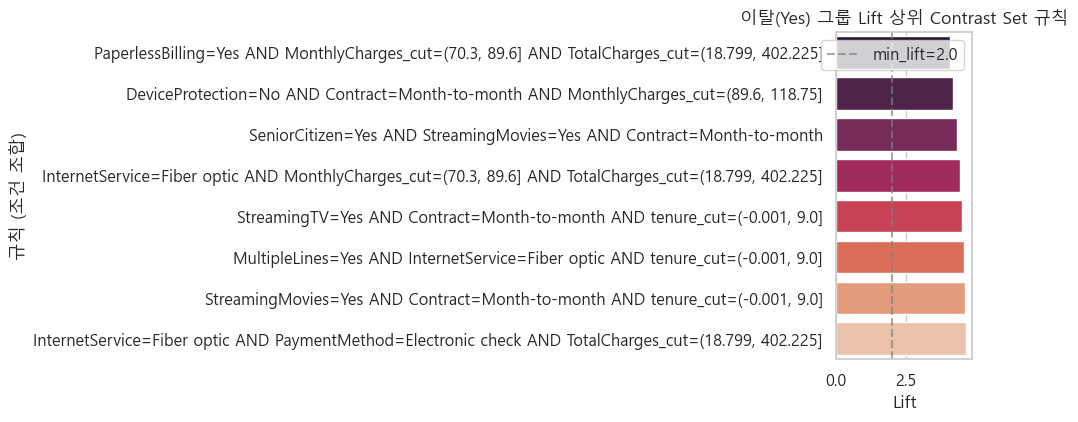

,rule,group,lift,rule_text
257,"(InternetService=>Fiber optic, PaymentMethod=>...",Yes,4.626094,InternetService=Fiber optic AND PaymentMethod=...
142,"(StreamingMovies=>Yes, Contract=>Month-to-mont...",Yes,4.591801,StreamingMovies=Yes AND Contract=Month-to-mont...
295,"(MultipleLines=>Yes, InternetService=>Fiber op...",Yes,4.556219,MultipleLines=Yes AND InternetService=Fiber op...
122,"(StreamingTV=>Yes, Contract=>Month-to-month, t...",Yes,4.485980,StreamingTV=Yes AND Contract=Month-to-month AN...
258,"(InternetService=>Fiber optic, MonthlyCharges_...",Yes,4.431675,InternetService=Fiber optic AND MonthlyCharges...


In [16]:
# [과제 2] 이탈(Yes) 그룹 lift 상위 규칙 확인 및 해석
def format_rule(rule_tuple):
    return " AND ".join(
        f"{part.split('=>', 1)[0]}={part.split('=>', 1)[1]}" for part in rule_tuple
    )


yes_rules = contrast_rules.loc[contrast_rules["group"] == "Yes"].copy()
yes_rules = yes_rules.sort_values("lift", ascending=False)
yes_rules["rule_text"] = yes_rules["rule"].apply(format_rule)

print("=" * 60)
print("[이탈(Yes) 그룹] Lift 상위 5개 규칙")
print("=" * 60)
for i, row in yes_rules.head(5).iterrows():
    print(f"Lift {row['lift']:.2f} | {row['rule_text']}")

# Lift 상위 규칙 시각화
top_n = min(8, len(yes_rules))
plot_df = yes_rules.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, max(4, top_n * 0.55)))
sns.barplot(data=plot_df, x="lift", y="rule_text", palette="rocket", ax=ax)
ax.set_title("이탈(Yes) 그룹 Lift 상위 Contrast Set 규칙")
ax.set_xlabel("Lift")
ax.set_ylabel("규칙 (조건 조합)")
ax.axvline(2.0, color="gray", linestyle="--", alpha=0.7, label="min_lift=2.0")
ax.legend()
plt.tight_layout()
plt.show()

yes_rules.head()

**[과제]** 가장 중요한 규칙에 해당하는 고객들의 실제 이탈률을 비교해서 해당 규칙이 실제로 유의미한지 검증해 보세요.

검증 대상 규칙: InternetService=Fiber optic AND PaymentMethod=Electronic check AND TotalCharges_cut=(18.799, 402.225]

    구분  고객 수  이탈(Yes) 수   이탈률
 규칙 해당   394        299 75.9%
규칙 미해당  6649       1570 23.6%

전체 이탈률: 26.5%


C:\Users\Admin\AppData\Local\Temp\ipykernel_30120\3342885191.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=compare_df, x="구분", y="이탈률", palette="Set2", ax=axes[0])


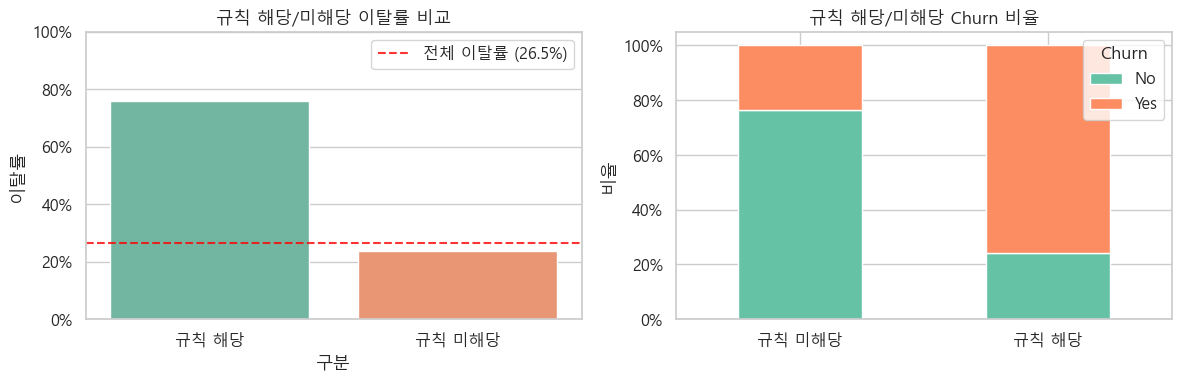

검증 대상 규칙: InternetService=Fiber optic AND PaymentMethod=Electronic check AND TotalCharges_cut=(18.799, 402.225]

    구분  고객 수  이탈(Yes) 수   이탈률
 규칙 해당   394        299 75.9%
규칙 미해당  6649       1570 23.6%

전체 이탈률: 26.5%


C:\Users\Admin\AppData\Local\Temp\ipykernel_30120\3342885191.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=compare_df, x="구분", y="이탈률", palette="Set2", ax=axes[0])


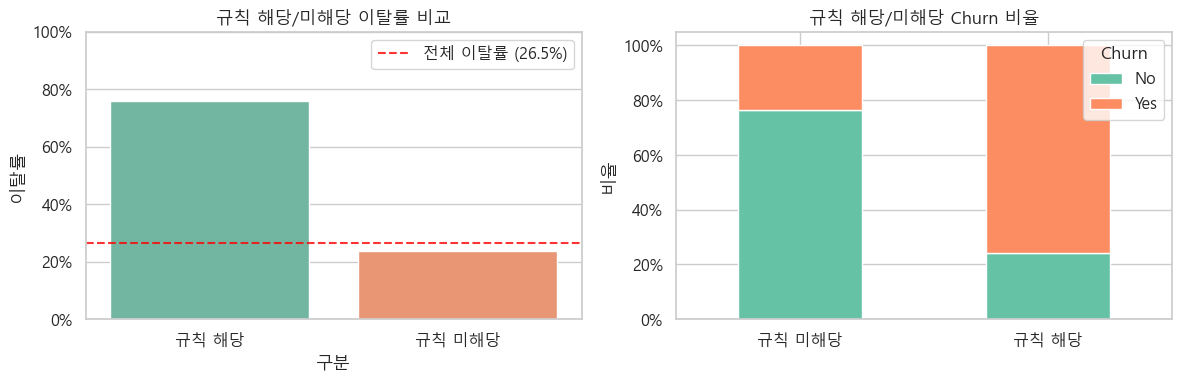

In [17]:
# [과제 3] 최상위 규칙의 실제 이탈률 검증
def rule_mask(encoded_df, rule_tuple):
    mask = pd.Series(True, index=encoded_df.index)
    for component in rule_tuple:
        feature = component.split("=>")[0]
        mask &= encoded_df[feature] == component
    return mask


top_rule = yes_rules.iloc[0]["rule"]
top_rule_text = yes_rules.iloc[0]["rule_text"]
cset_mask = rule_mask(stucco_data, top_rule)

compare_df = pd.DataFrame({
    "구분": ["규칙 해당", "규칙 미해당"],
    "고객 수": [cset_mask.sum(), (~cset_mask).sum()],
    "이탈(Yes) 수": [
        (data.loc[cset_mask, "Churn"] == "Yes").sum(),
        (data.loc[~cset_mask, "Churn"] == "Yes").sum(),
    ],
})
compare_df["이탈률"] = compare_df["이탈(Yes) 수"] / compare_df["고객 수"]
overall_yes_rate = (data["Churn"] == "Yes").mean()

print("검증 대상 규칙:", top_rule_text)
print()
print(compare_df.to_string(index=False, formatters={"이탈률": "{:.1%}".format}))
print(f"\n전체 이탈률: {overall_yes_rate:.1%}")

# 규칙 해당 vs 미해당 이탈률 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=compare_df, x="구분", y="이탈률", palette="Set2", ax=axes[0])
axes[0].axhline(overall_yes_rate, color="red", linestyle="--", alpha=0.8,
                label=f"전체 이탈률 ({overall_yes_rate:.1%})")
axes[0].set_title("규칙 해당/미해당 이탈률 비교")
axes[0].set_ylabel("이탈률")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0].legend()

churn_compare = pd.crosstab(
    pd.Series(np.where(cset_mask, "규칙 해당", "규칙 미해당"), name="구분"),
    data["Churn"],
    normalize="index",
)
churn_compare.plot(kind="bar", stacked=True, color=["#66c2a5", "#fc8d62"], ax=axes[1])
axes[1].set_title("규칙 해당/미해당 Churn 비율")
axes[1].set_xlabel("")
axes[1].set_ylabel("비율")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[1].legend(title="Churn", loc="upper right")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.show()

compare_df = pd.DataFrame({
    "구분": ["규칙 해당", "규칙 미해당"],
    "고객 수": [cset_mask.sum(), (~cset_mask).sum()],
    "이탈(Yes) 수": [
        (data.loc[cset_mask, "Churn"] == "Yes").sum(),
        (data.loc[~cset_mask, "Churn"] == "Yes").sum(),
    ],
})
compare_df["이탈률"] = compare_df["이탈(Yes) 수"] / compare_df["고객 수"]
overall_yes_rate = (data["Churn"] == "Yes").mean()

print("검증 대상 규칙:", top_rule_text)
print()
print(compare_df.to_string(index=False, formatters={"이탈률": "{:.1%}".format}))
print(f"\n전체 이탈률: {overall_yes_rate:.1%}")

# 규칙 해당 vs 미해당 이탈률 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=compare_df, x="구분", y="이탈률", palette="Set2", ax=axes[0])
axes[0].axhline(overall_yes_rate, color="red", linestyle="--", alpha=0.8,
                label=f"전체 이탈률 ({overall_yes_rate:.1%})")
axes[0].set_title("규칙 해당/미해당 이탈률 비교")
axes[0].set_ylabel("이탈률")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0].legend()

churn_compare = pd.crosstab(
    pd.Series(np.where(cset_mask, "규칙 해당", "규칙 미해당"), name="구분"),
    data["Churn"],
    normalize="index",
)
churn_compare.plot(kind="bar", stacked=True, color=["#66c2a5", "#fc8d62"], ax=axes[1])
axes[1].set_title("규칙 해당/미해당 Churn 비율")
axes[1].set_xlabel("")
axes[1].set_ylabel("비율")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[1].legend(title="Churn", loc="upper right")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.show()